In [110]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [111]:
def plot_3d_vectors(vectors):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    for ix, vector in enumerate(vectors):
        ax.quiver(0, 0, 0, vector[0], vector[1], vector[2])
    ax.set_xlim((0, vectors[:, 0].max()))
    ax.set_ylim((0, vectors[:, 1].max()))
    ax.set_zlim((0, vectors[:, 2].max()))
    plt.show()
    
    

In [112]:
from utils.vision.embeddings.dino_pipeline import DinoPipeline
from utils.vision.embeddings.vit_pipeline import VitPipeline

In [113]:
Dinopipeline = DinoPipeline()
Vitpipeline = VitPipeline()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [114]:
from PIL import Image

In [115]:
im1 = Image.open('data/examples/offroad/rugd_images_all/0046.png')
im2 = Image.open('data/examples/offroad/rugd_images_all/0047.png')
im3 = Image.open('data/examples/offroad/rugd_images_all/0051.png')

In [116]:
query_img = Image.open('data/examples/offroad/rugd_images_all/0430.png')

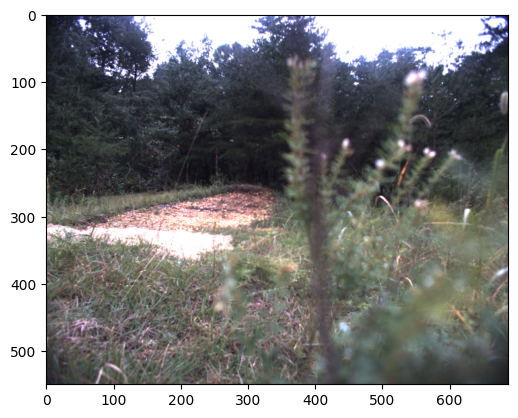

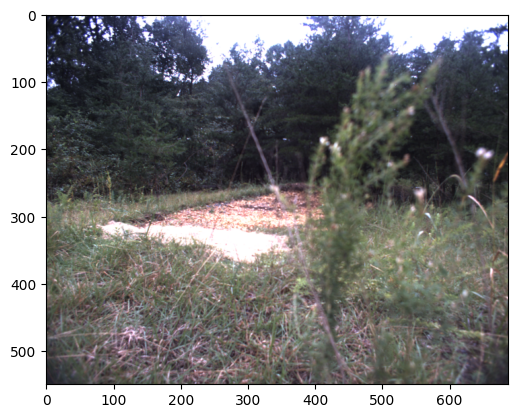

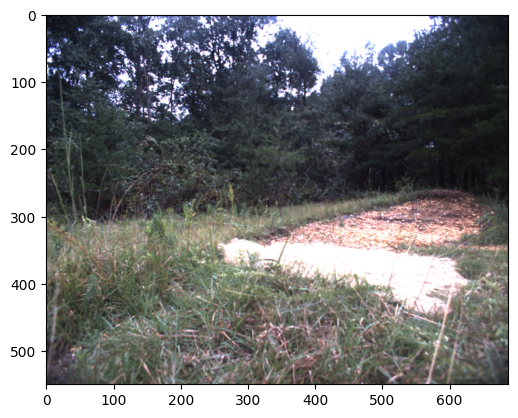

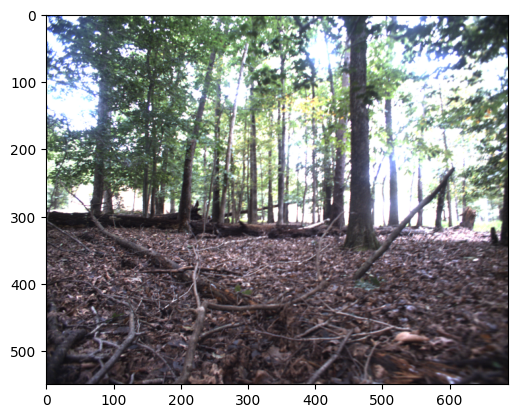

In [117]:
#visualise images
plt.imshow(im1)
plt.show()
plt.imshow(im2)
plt.show()
plt.imshow(im3)
plt.show()
plt.imshow(query_img)
plt.show()

In [118]:
dino_embeddings = Dinopipeline([im1, im2, im3])
vit_embeddings = Vitpipeline([im1, im2, im3])

In [119]:
query_embedding_dino = Dinopipeline(query_img)
query_embedding_vit = Vitpipeline(query_img)

In [120]:
dino_embeddings.shape, vit_embeddings.shape

((3, 768), (3, 768))

In [121]:
#get similarity between query  and embeddings
similarity = torch.nn.CosineSimilarity()
for embedding in dino_embeddings:
    print(similarity(torch.Tensor(query_embedding_dino), torch.Tensor(embedding)))

tensor([0.4050])
tensor([0.4174])
tensor([0.5046])


In [122]:
#get similarity between query  and embeddings
similarity = torch.nn.CosineSimilarity()
for embedding in vit_embeddings:
    # print(query_embedding_vit.shape, embedding.shape)
    print(similarity(torch.Tensor(query_embedding_vit), torch.Tensor(embedding)))

tensor([0.3067])
tensor([0.3373])
tensor([0.3606])


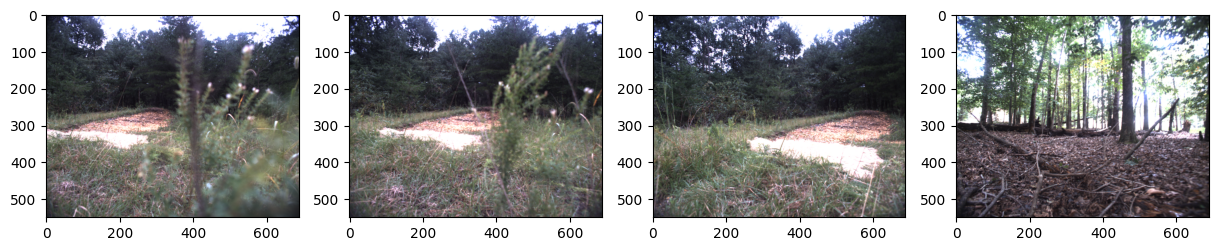

In [123]:
#plot images
fig, axs = plt.subplots(1, 4)
#increase figsize
fig.set_figheight(15)
fig.set_figwidth(15)

axs[0].imshow(im1)
axs[1].imshow(im2)
axs[2].imshow(im3)
axs[3].imshow(query_img)

In [124]:
import numpy as np
from transformers import AutoImageProcessor, AutoModel
import torch

In [125]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base').to('cuda')
        

In [126]:
inputs = processor(images=[im1, im2, im3], return_tensors="pt").to('cuda')
outputs = model(**inputs)

In [127]:
outputs.last_hidden_state.shape

torch.Size([3, 257, 768])

In [128]:
outputs.last_hidden_state.mean(dim=1).shape

torch.Size([3, 768])